# Forecast Evaluation

In this stage, we evaluate the effectiveness of GARCH volatility forecasts.

Objectives:
1. Compare predicted volatility with realized volatility
2. Measure forecast accuracy
3. Analyze forecasting behavior during volatile periods
4. Assess usefulness of GARCH-based volatility forecasts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
sp500 = pd.read_csv("../data/SP500_processed.csv", index_col="Date", parse_dates=True)
btc = pd.read_csv("../data/BTC_processed.csv", index_col="Date", parse_dates=True)

In [3]:
split_index = int(len(sp500) * 0.8)

train = sp500["log_return"][:split_index] * 100
test = sp500["log_return"][split_index:] * 100

In [4]:
model = arch_model(train, vol="Garch", p=1, q=1)

result = model.fit(disp="off")

In [5]:
forecasts = []

for i in range(len(test)):
    
    train_data = sp500["log_return"][:split_index + i] * 100
    
    model = arch_model(train_data, vol="Garch", p=1, q=1)
    
    result = model.fit(disp="off")
    
    pred = result.forecast(horizon=1)
    
    forecasts.append(
        np.sqrt(pred.variance.values[-1, :][0])
    )

In [6]:
realized_vol = np.abs(test.values)

In [7]:
rmse = np.sqrt(mean_squared_error(realized_vol, forecasts))

mae = mean_absolute_error(realized_vol, forecasts)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.7594864259376064
MAE: 0.5301809192793779


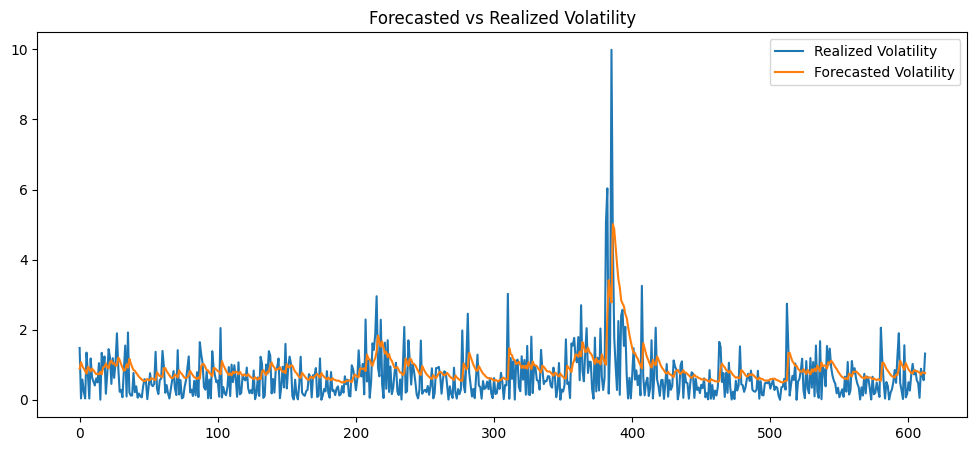

In [8]:
plt.figure(figsize=(12,5))

plt.plot(realized_vol, label="Realized Volatility")

plt.plot(forecasts, label="Forecasted Volatility")

plt.legend()

plt.title("Forecasted vs Realized Volatility")

plt.show()

## Forecast Evaluation Interpretation

The GARCH model captures major volatility spikes reasonably well, although forecast smoothness may lag during sudden market shocks.

Forecast errors arise because financial volatility is highly dynamic and partially unpredictable.

Nevertheless, the model successfully captures volatility persistence and clustering behavior.